<a href="https://colab.research.google.com/github/asiddiqha/ML_Practice/blob/main/LoanApprovalPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Loan Approval Prediction using Machine Learning

## Problem Statement

The objective of this project is to predict whether a loan application will be approved based on applicant details such as income, credit score, loan amount, employment status, education level, and other financial attributes.

The project follows a complete machine learning workflow including data preprocessing, exploratory data analysis (EDA), feature engineering, model training, evaluation, and prediction using classification algorithms.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [ ]:
df = pd.read_csv('logistic_sample.csv')
df.head()

,Applicant_ID,Age,Annual_Income (₹ Lakhs),Credit_Score,Loan_Amount (₹ Lakhs),Employment,Married,Dependents,Education,Property_Area,Loan_Approved
0,A001,24,3.2,620,2.0,Salaried,No,0,Graduate,Urban,No
1,A002,27,4.5,680,2.5,Salaried,Yes,1,Graduate,Urban,Yes
2,A003,30,5.8,710,3.0,Business,Yes,2,Graduate,Semiurban,Yes
3,A004,22,2.8,600,2.2,Salaried,No,0,Graduate,Rural,No
4,A005,35,8.5,760,4.0,Business,Yes,2,Post Graduate,Urban,Yes


In [ ]:
df.shape

(30, 11)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Applicant_ID             30 non-null     object 
 1   Age                      30 non-null     int64  
 2   Annual_Income (₹ Lakhs)  30 non-null     float64
 3   Credit_Score             30 non-null     int64  
 4   Loan_Amount (₹ Lakhs)    30 non-null     float64
 5   Employment               30 non-null     object 
 6   Married                  30 non-null     object 
 7   Dependents               30 non-null     int64  
 8   Education                30 non-null     object 
 9   Property_Area            30 non-null     object 
 10  Loan_Approved            30 non-null     object 
dtypes: float64(2), int64(3), object(6)
memory usage: 2.7+ KB


In [ ]:
df.describe()

,Age,Annual_Income (₹ Lakhs),Credit_Score,Loan_Amount (₹ Lakhs),Dependents
count,30.000000,30.000000,30.000000,30.00000,30.000000
mean,30.500000,5.856667,702.500000,3.41000,1.333333
std,6.067153,2.403113,66.355235,1.16185,1.093345
min,21.000000,2.500000,590.000000,1.80000,0.000000
25%,26.000000,3.925000,651.250000,2.52500,0.000000
50%,29.500000,5.550000,707.500000,3.15000,1.000000
75%,35.000000,7.725000,753.750000,4.22500,2.000000
max,42.000000,11.000000,820.000000,6.00000,3.000000


In [ ]:
df.isnull().sum()

,0
Applicant_ID,0
Age,0
Annual_Income (₹ Lakhs),0
Credit_Score,0
Loan_Amount (₹ Lakhs),0
Employment,0
Married,0
Dependents,0
Education,0
Property_Area,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.columns

Index(['Applicant_ID', 'Age', 'Annual_Income (₹ Lakhs)', 'Credit_Score',
       'Loan_Amount (₹ Lakhs)', 'Employment', 'Married', 'Dependents',
       'Education', 'Property_Area', 'Loan_Approved'],
      dtype='object')

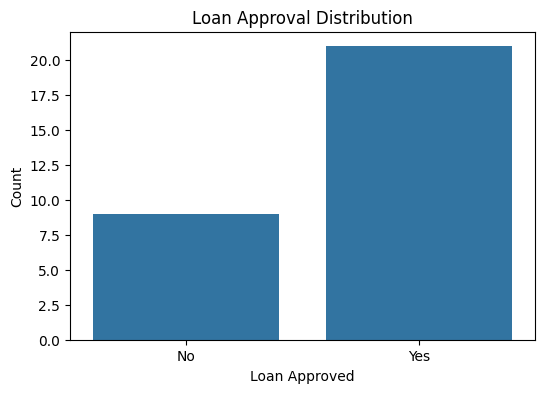

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='Loan_Approved')

plt.title('Loan Approval Distribution')
plt.xlabel('Loan Approved')
plt.ylabel('Count')

plt.show()

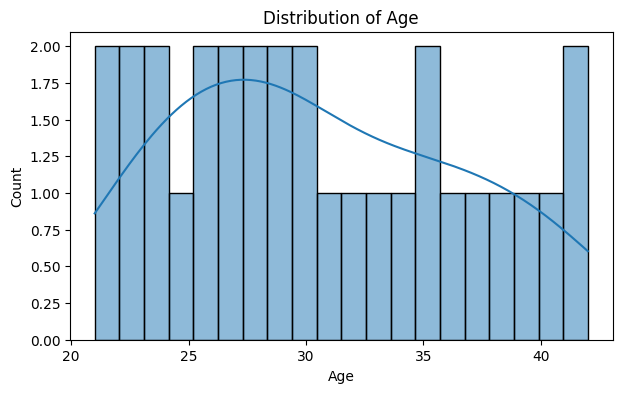

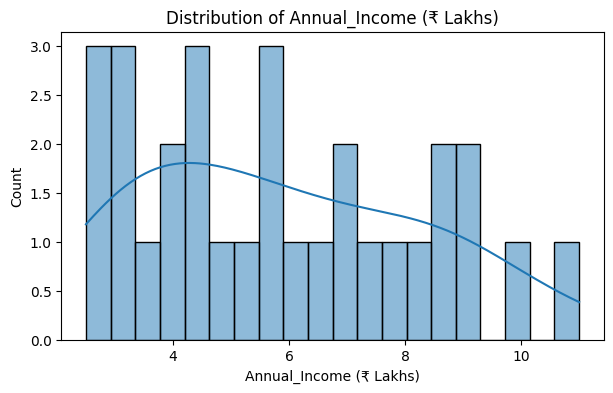

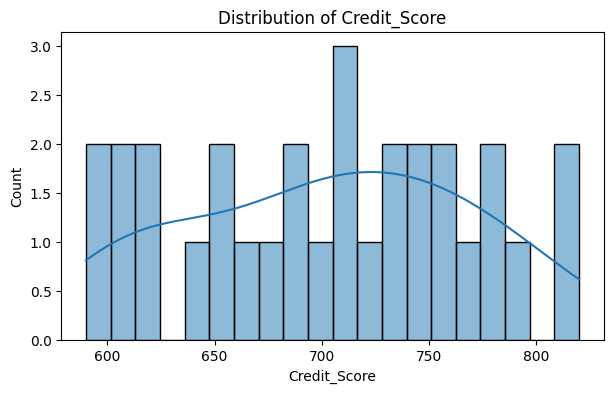

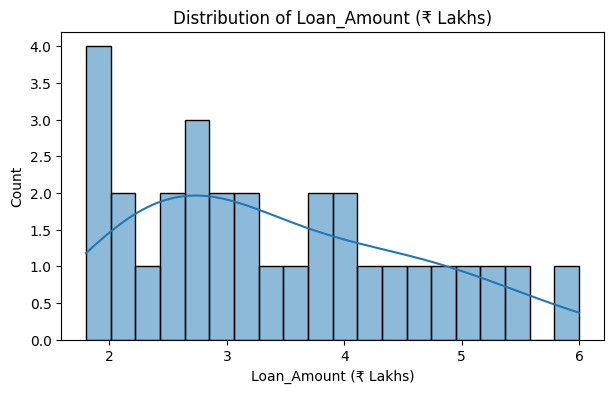

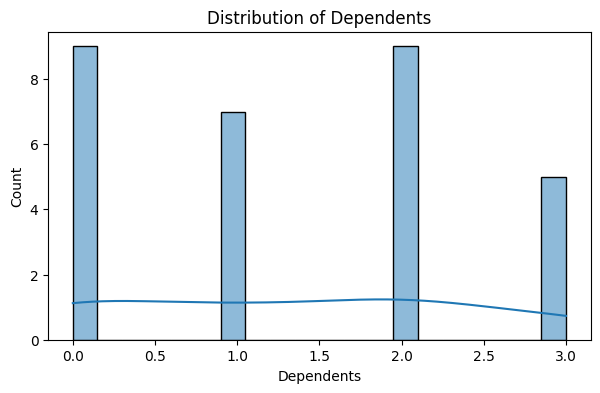

In [ ]:
numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    plt.figure(figsize=(7,4))

    sns.histplot(df[col], kde=True, bins=20)

    plt.title(f'Distribution of {col}')

    plt.show()

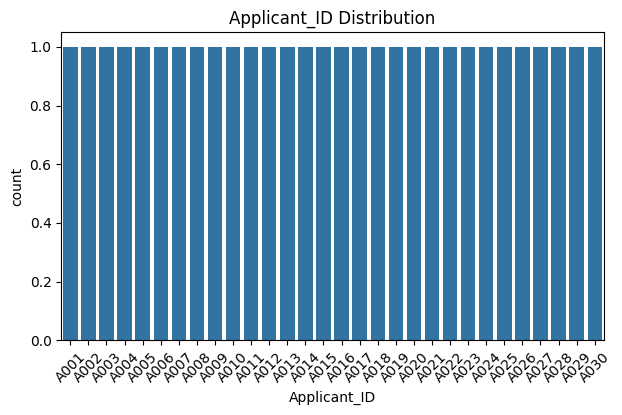

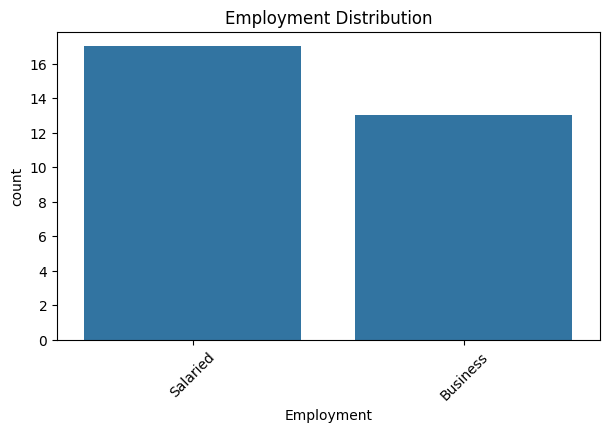

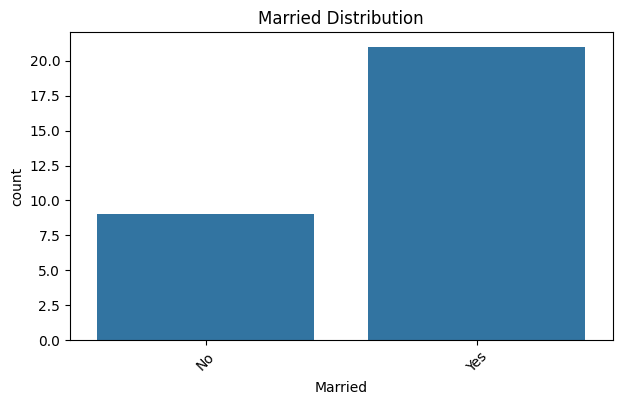

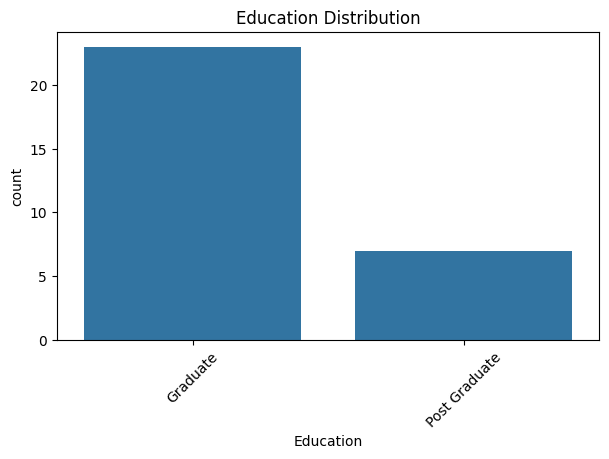

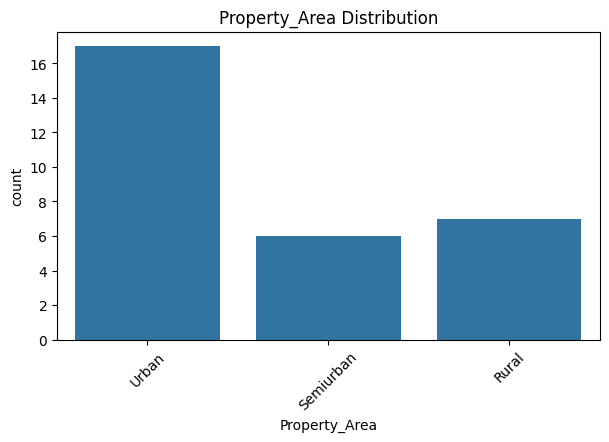

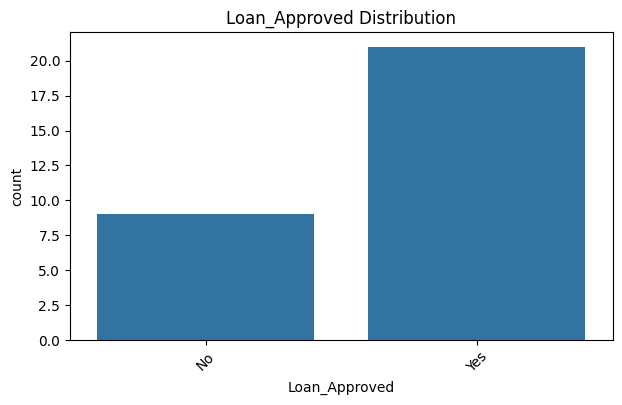

In [ ]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    plt.figure(figsize=(7,4))

    sns.countplot(data=df, x=col)

    plt.title(f'{col} Distribution')

    plt.xticks(rotation=45)

    plt.show()

In [ ]:
df.drop(columns=['Applicant_ID'], inplace=True)

In [ ]:
le = LabelEncoder()

categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

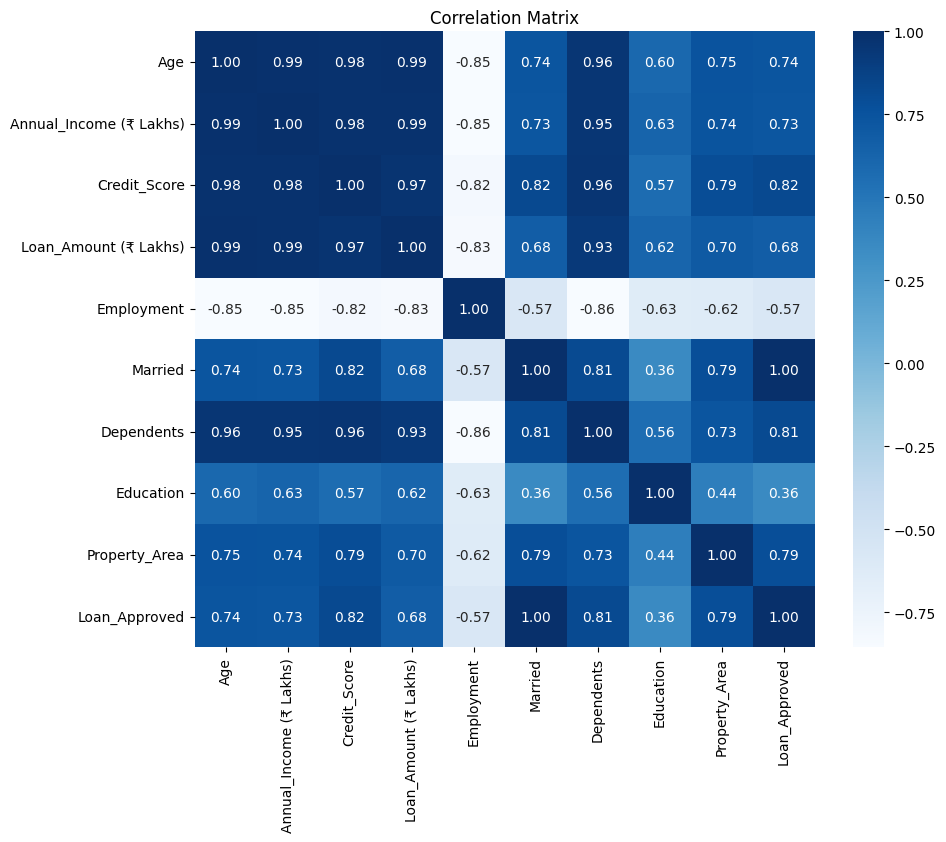

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='Blues',
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [ ]:
X = df.drop('Loan_Approved', axis=1)

y = df['Loan_Approved']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [ ]:
logistic_model = LogisticRegression(random_state=42)
logistic_model.fit(X_train_scaled, y_train)
logistic_pred = logistic_model.predict(X_test_scaled)

In [ ]:
print("Logistic Regression Performance")
print("-" * 40)

print(f"Accuracy : {accuracy_score(y_test, logistic_pred):.4f}")
print(f"Precision: {precision_score(y_test, logistic_pred):.4f}")
print(f"Recall   : {recall_score(y_test, logistic_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, logistic_pred):.4f}")

print("\nClassification Report")
print(classification_report(y_test, logistic_pred))

print("Confusion Matrix")
print(confusion_matrix(y_test, logistic_pred))

Logistic Regression Performance
----------------------------------------
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         4

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6

Confusion Matrix
[[2 0]
 [0 4]]


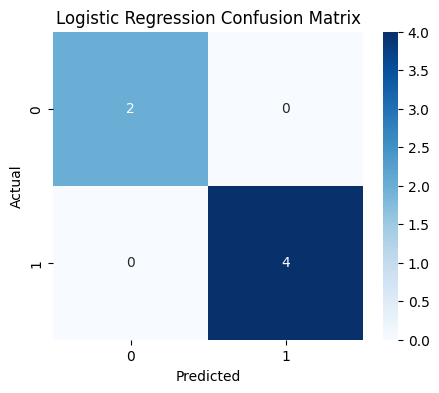

In [ ]:
cm = confusion_matrix(y_test, logistic_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
decision_model = DecisionTreeClassifier(random_state=42)
decision_model.fit(X_train, y_train)
decision_pred = decision_model.predict(X_test)

In [ ]:
print("Decision Tree Classifier Performance")
print("-" * 40)

print(f"Accuracy : {accuracy_score(y_test, decision_pred):.4f}")
print(f"Precision: {precision_score(y_test, decision_pred):.4f}")
print(f"Recall   : {recall_score(y_test, decision_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, decision_pred):.4f}")

print("\nClassification Report")
print(classification_report(y_test, decision_pred))

print("Confusion Matrix")
print(confusion_matrix(y_test, decision_pred))

Decision Tree Classifier Performance
----------------------------------------
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         4

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6

Confusion Matrix
[[2 0]
 [0 4]]


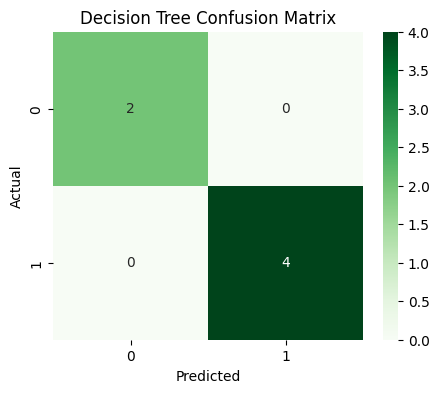

In [ ]:
cm = confusion_matrix(y_test, decision_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test, logistic_pred),
        accuracy_score(y_test, decision_pred)
    ],
    "Precision": [
        precision_score(y_test, logistic_pred),
        precision_score(y_test, decision_pred)
    ],
    "Recall": [
        recall_score(y_test, logistic_pred),
        recall_score(y_test, decision_pred)
    ],
    "F1 Score": [
        f1_score(y_test, logistic_pred),
        f1_score(y_test, decision_pred)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,1.0,1.0,1.0,1.0
1,Decision Tree,1.0,1.0,1.0,1.0


In [ ]:
sample = X_test.iloc[[0]]

logistic_prediction = logistic_model.predict(
    scaler.transform(sample)
)

decision_prediction = decision_model.predict(sample)

print("Actual Loan Status:", y_test.iloc[0])
print("Logistic Regression Prediction:", logistic_prediction[0])
print("Decision Tree Prediction:", decision_prediction[0])

Actual Loan Status: 1
Logistic Regression Prediction: 1
Decision Tree Prediction: 1
